In [10]:
# set up the python
import cosima_cookbook as cc
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid

In [11]:
client = Client(n_workers=28)
client

Perhaps you already have a cluster running?
Hosting the HTTP server on port 37341 instead
  warnings.warn(



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/37341/status,
Dashboard: /proxy/37341/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41105,Workers: 28
Dashboard: /proxy/37341/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:39599,Total threads: 1
Dashboard: /proxy/38789/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:37795,


In [12]:
session = cc.database.create_session()
db = '/g/data/x77/hm1221/CDW_changes/Jupyter_notebooks/RYF_perturbation_1.db'
session1 = cc.database.create_session(db)

In [13]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [14]:
# time period
start_time = '2140-01-01'
end_time = '2164-12-31'

In [15]:
# time period for map
start_time1 = '2160-01-01'
end_time1 = '2164-12-31'

start_time2 = '2151-12-01'
end_time2 = '2154-12-31'


In [16]:
# time period
start_time3 = '2150-01-01'
end_time3 = '2164-12-31'

In [17]:
#load T
temp_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='temp', 
                          session=session, frequency='1 monthly').sel(time = slice(start_time, end_time))
temp_wt = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585', variable='temp', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time3, end_time3))
temp_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='temp', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time3, end_time3))

ERROR:sqlalchemy.pool.impl.NullPool:Exception during reset or similar
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/sqlalchemy/pool/base.py", line 763, in _finalize_fairy
    fairy._reset(pool, transaction_was_reset)
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/sqlalchemy/pool/base.py", line 1038, in _reset
    pool._dialect.do_rollback(self)
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/sqlalchemy/engine/default.py", line 683, in do_rollback
    dbapi_connection.rollback()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 23148648699712 and this is thread id 23140507842304.
ERROR:sqlalchemy.pool.impl.NullPool:Exception closing connection <sqlite3.Connection object at 0x150bd9645b70>
Traceback (most recent call last):
  File "/g

In [18]:
# read practical salinity
# time period
salt_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='salt', 
                          session=session, frequency='1 monthly').sel(time = slice(start_time, end_time))
salt_wt = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585', variable='salt', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))

salt_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='salt', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks

In [19]:
shelf_mask = xr.open_dataarray('/scratch/x77/hm1221/nc_files/shelf_mask.nc')

st_ocean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/st_ocean.nc')

In [20]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [21]:
# calculate the mean state
def temp_400m(temp):
    temp_400 = temp.sel(yt_ocean = slice(-90,-50)).sel(st_ocean = 400., method = 'nearest').load()
    temp_400_mean = temp_400.where(shelf_mask<0.8).load()
    temp_400_mean_5yr = temp_400.sel(time = slice(start_time1,end_time1)).mean('time').load()
    temp_400_mean =  temp_400_mean.mean(('xt_ocean','yt_ocean')).load()

    return [temp_400_mean_5yr,temp_400_mean]

In [22]:
temp_400_mean_ctrl_5yr,temp_400_mean_ctrl = temp_400m(temp_ctrl)
temp_400_mean_th_5yr,temp_400_mean_th = temp_400m(temp_th)
temp_400_mean_wt_5yr,temp_400_mean_wt = temp_400m(temp_wt)

In [23]:
dT_400_th = temp_400_mean_th[1:-1].values - temp_400_mean_th[0:-2].values
dT_400_ctrl = temp_400_mean_ctrl[1:-1].values - temp_400_mean_ctrl[0:-2].values

In [24]:
dT_400_th = xr.DataArray(dT_400_th, dims  = ['time'], coords = [temp_400_mean_th[1:-1].time])
dT_400_ctrl = xr.DataArray(dT_400_ctrl, dims  = ['time'], coords = [temp_400_mean_ctrl[1:-1].time])

In [25]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

In [26]:
custom_x_ctrl = np.concatenate([
    np.linspace(0, 0.25, 120),
    np.linspace(0.25, 1, 180)
])
custom_x_pert = np.linspace(0.25, 1, 180)
custom_ticks = np.concatenate([
    np.linspace(0.0, 0.25, 11),
    np.linspace(0.25, 1, 16)
])
custom_tick_labels = ['Spin-up','','','','','','','','','','', '0','1', '2', '3', '4', '5', '6', '7', '8','9','10','11','12',
                      '13','14','15']

In [27]:
data = xr.Dataset({
    'Control': temp_400_mean_ctrl_5yr,
    'Wind+Thermal': temp_400_mean_wt_5yr -temp_400_mean_ctrl_5yr,
    'Thermal': temp_400_mean_th_5yr-temp_400_mean_ctrl_5yr,
})

In [28]:
# land mask
land = xr.where(np.isnan(temp_400_mean_ctrl_5yr[:,:].rename('land')), 1, np.nan)

# Now, calculate the transect

In [19]:
def var_mean_5yr(var):
    var_mean_5yr = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()

    return var_mean_5yr

In [20]:
temp_ctrl_mean = var_mean_5yr(temp_ctrl)
temp_th_mean = var_mean_5yr(temp_th)
temp_wt_mean = var_mean_5yr(temp_wt)
salt_ctrl_mean = var_mean_5yr(salt_ctrl)
salt_th_mean = var_mean_5yr(salt_th)
salt_wt_mean = var_mean_5yr(salt_wt)

In [21]:
def sigma1(temp,salt):
    # practical salinity to absolute salinity
    salt = gsw.conversions.SA_from_SP(salt,salt.st_ocean,salt.xt_ocean,salt.yt_ocean)
    # conservative temp and absolute salinity to sigma1
    rho = gsw.density.sigma1(salt, temp-273.15)

    return rho

In [22]:
rho_ctrl_mean = sigma1(temp_ctrl_mean,salt_ctrl_mean)
rho_th_mean = sigma1(temp_th_mean,salt_th_mean)
rho_wt_mean = sigma1(temp_wt_mean,salt_wt_mean)

In [23]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [24]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [25]:
temp_ctrl_new,temp_ctrl_mean_new = Trans_lat_to_shelf(temp_ctrl_mean,new_coord)
temp_th_new,temp_th_mean_new = Trans_lat_to_shelf(temp_th_mean,new_coord)
temp_wt_new,temp_wt_mean_new = Trans_lat_to_shelf(temp_wt_mean,new_coord)

rho_th_new,rho_th_mean_new = Trans_lat_to_shelf(rho_th_mean,new_coord)
rho_ctrl_new,rho_ctrl_mean_new = Trans_lat_to_shelf(rho_ctrl_mean,new_coord)
rho_wt_new,rho_wt_mean_new = Trans_lat_to_shelf(rho_wt_mean,new_coord)

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(

  warnings.warn(



In [26]:
rho_wt_mean_new.to_netcdf("/scratch/x77/hm1221/nc_files/rho_wt_mean_new.nc")

# Fig in the manuscript

In [27]:
levs_dens = [32.0,32.3,32.5]

([<matplotlib.axis.XTick at 0x151138788150>,
 [Text(0.0, 0, 'Spin-up'),
  Text(0.025, 0, ''),
  Text(0.05, 0, ''),
  Text(0.07500000000000001, 0, ''),
  Text(0.1, 0, ''),
  Text(0.125, 0, ''),
  Text(0.15000000000000002, 0, ''),
  Text(0.17500000000000002, 0, ''),
  Text(0.2, 0, ''),
  Text(0.225, 0, ''),
  Text(0.25, 0, '0'),
  Text(0.25, 0, '0'),
  Text(0.3, 0, '1'),
  Text(0.35, 0, '2'),
  Text(0.4, 0, '3'),
  Text(0.45, 0, '4'),
  Text(0.5, 0, '5'),
  Text(0.55, 0, '6'),
  Text(0.6000000000000001, 0, '7'),
  Text(0.65, 0, '8'),
  Text(0.7, 0, '9'),
  Text(0.75, 0, '10'),
  Text(0.8, 0, '11'),
  Text(0.8500000000000001, 0, '12'),
  Text(0.9, 0, '13'),
  Text(0.9500000000000001, 0, '14'),
  Text(1.0, 0, '15')])

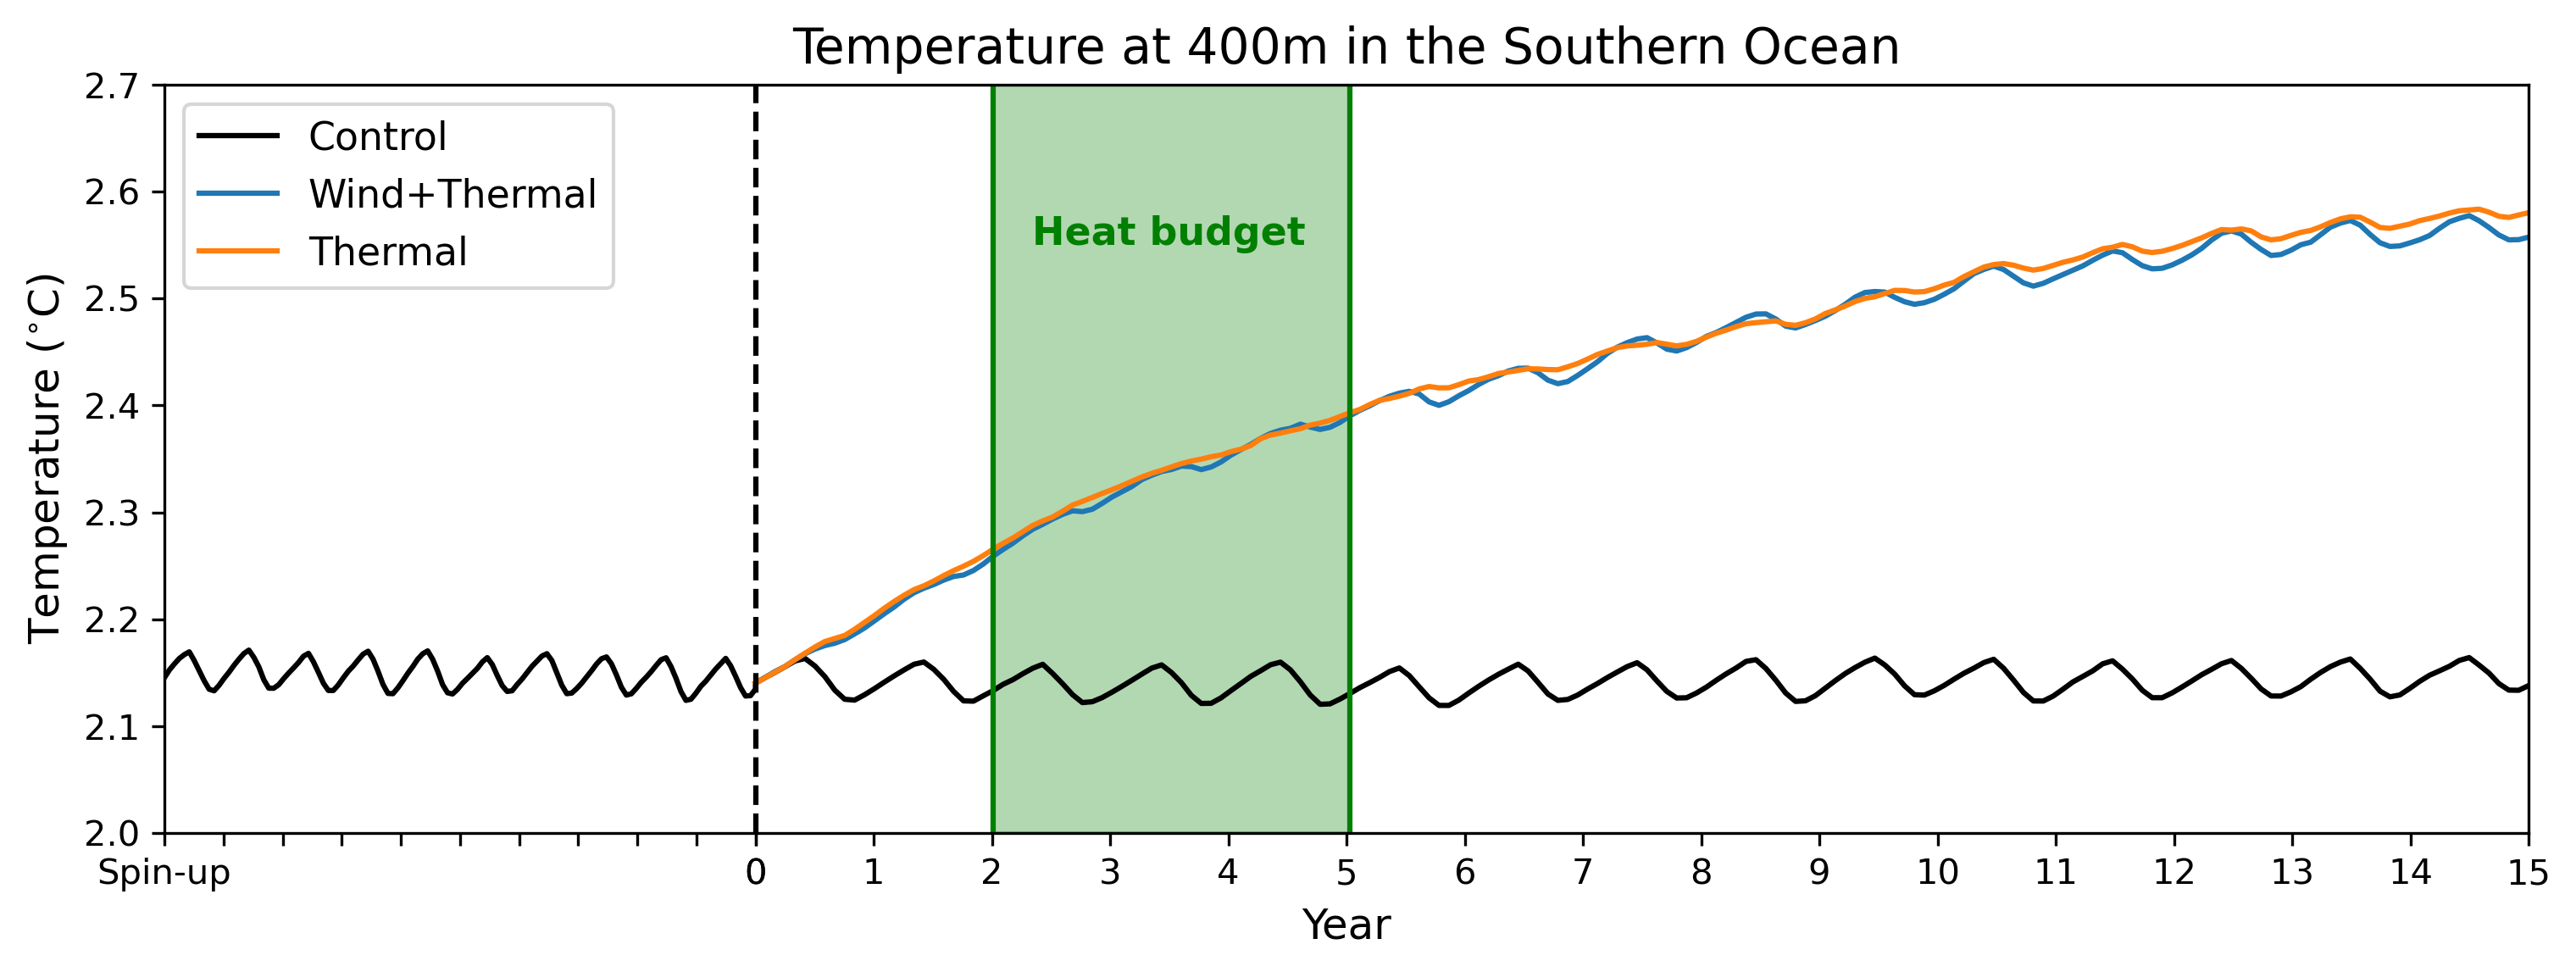

In [32]:
# for Figure 3
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
fig = plt.figure(figsize=(12,13),dpi = 300)
ax1 = plt.subplot(3,1,1)
ax1.plot(custom_x_ctrl,temp_400_mean_ctrl.values-273.15,linewidth = 1.5, color='k')
ax1.plot(custom_x_pert,temp_400_mean_wt[3:].values-273.15,linewidth = 1.5)
ax1.plot(custom_x_pert,temp_400_mean_th[3:].values-273.15,linewidth = 1.5)
ax1.plot([custom_x_ctrl[120],custom_x_ctrl[120]], [2.,2.7], linestyle='--', color='k', label='Dashed Line Data')
ax1.plot([custom_x_ctrl[144],custom_x_ctrl[144]], [2.,2.7], linestyle='-', color='green', label='Dashed Line Data')
ax1.plot([custom_x_ctrl[180],custom_x_ctrl[180]], [2.,2.7], linestyle='-', color='green', label='Dashed Line Data')
ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'g',fontweight='bold')
plt.ylim(2.,2.7)
ax1.margins(x=0.0)  
plt.legend(['Control','Wind+Thermal','Thermal'],fontsize = 11, loc = 'upper left')
plt.ylabel('Temperature ($^{\circ}$C)', fontsize = 12)
plt.xlabel('Year', fontsize = 12)
plt.axvspan(custom_x_ctrl[144], custom_x_ctrl[180], color='green', alpha=0.3)
#ax2 = ax1.twinx()
#ax2.plot(custom_x_pert[2:],(dT_400_th[3:].values-dT_400_ctrl[120:].values),color = 'brown',linestyle='--',linewidth = 1.5)
plt.title('Temperature at 400m in the Southern Ocean', fontsize = 14)
#plt.plot([2152,2152], [2.0,2.7], linestyle='--', color='k')
#plt.plot([2154,2154], [2.0,2.7], linestyle='--', color='k')
plt.xlabel('Year', fontsize = 12)
plt.xticks(custom_ticks, custom_tick_labels)
#ax2.tick_params(axis='y', labelcolor='brown')
#ax1.text(
#        0.0, 1.08, '(a)', transform=ax1.transAxes, fontweight='bold', 
#        fontsize=13,  # Font size
#        verticalalignment='top',  # Align text vertically to the top
#        horizontalalignment='left',  # Align text horizontally to the left
#)
#plt.ylabel('temperature tendency anomaly ($^{\circ}$C/month)', fontsize = 10,color='brown')
#plt.ylim(-0.01,0.02)

Text(0, 0.5, 'Temperature anomaly ($^{\\circ}$C)')

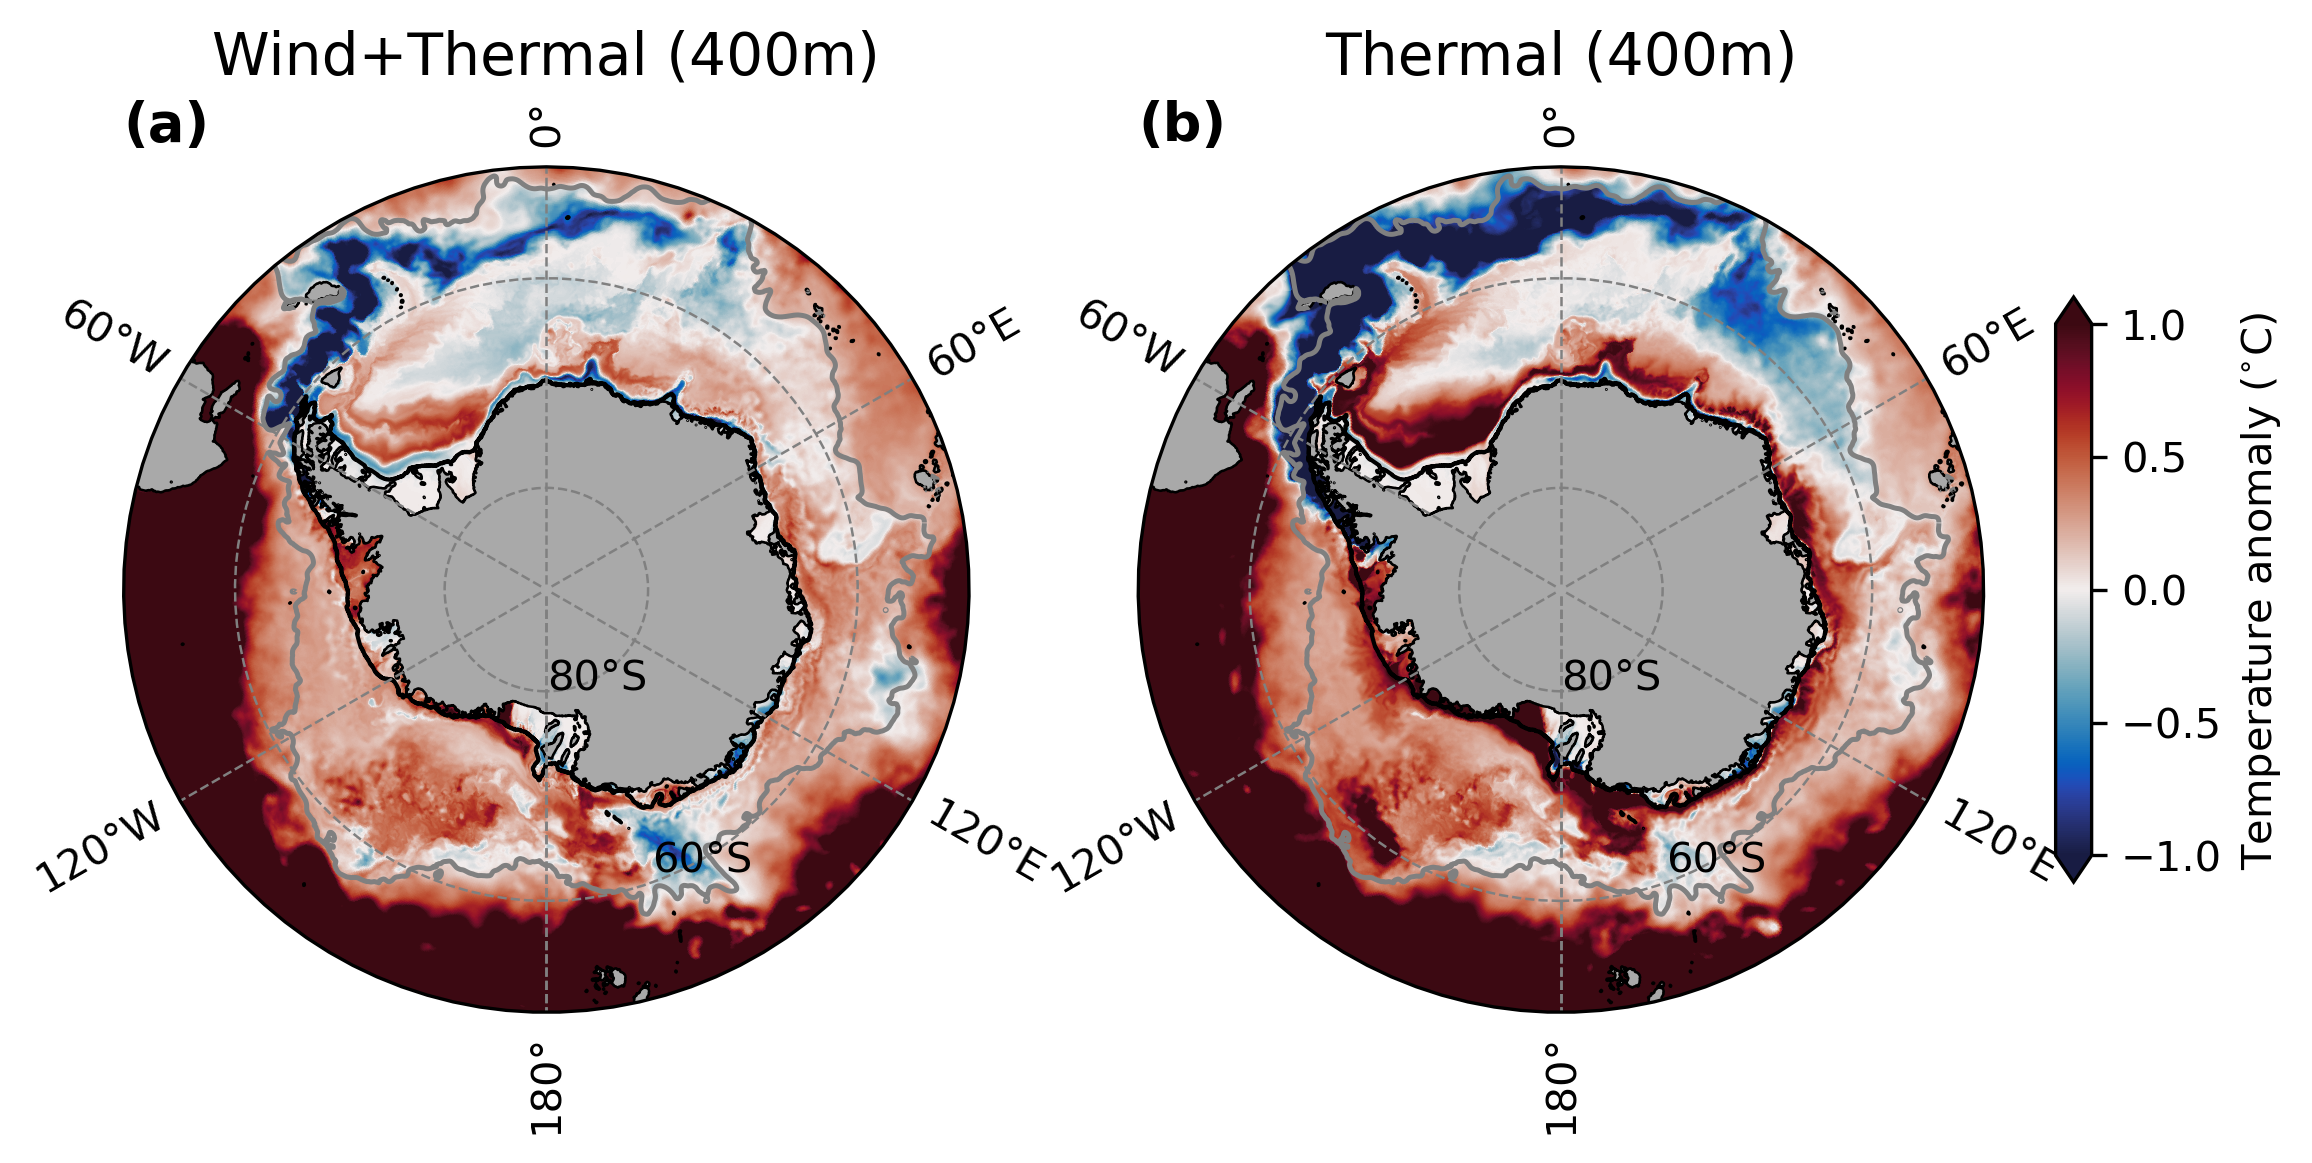

In [29]:
# For Figure 4
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
fig = plt.figure(figsize=(8,13),dpi = 300)
for j in range(2):
    variable_name = ['Wind+Thermal','Thermal'][j]
    order = ['(a)','(b)'][j]
    projection=ccrs.SouthPolarStereo()
    ax = plt.subplot(3,2,j+3,projection = projection,facecolor="darkgrey")
    theta = np.linspace(0,2*np.pi,100)
    center,radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    p2 = (data[variable_name]).plot(ax=ax, vmin = -1,vmax = 1, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.balance,add_colorbar = False)
    land[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
    land[:,:].fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 0.6)
    data['Control'].plot.contour(ax=ax, levels=[273.15+2.8], colors='grey', linewidths = 1.2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
    ax.text(
        0.0, 1.08, f'{order}', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
    )
    plt.plot(x_shelf, y_shelf, linewidth=1,color='black',transform=ccrs.PlateCarree())
    ax.set_title(f'{variable_name}'+' (400m)', fontsize = 14)

    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        xlocs=np.arange(-180, 181, 60),
        ylocs=np.arange(-80, -49, 20),
        linewidth=0.6, linestyle='--', color='0.5', draw_labels=True
    )
# colorbar 
ax_cb2 = plt.axes([0.93, 0.42, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature anomaly ($^{\circ}$C)', fontsize = 10)

In [30]:
background_1 = xr.DataArray(
    data=np.ones_like(temp_ctrl_mean_new),
    coords=temp_ctrl_mean_new.coords,
    dims=temp_ctrl_mean_new.dims,
    name='ones_array'
)

Text(0, 0.5, 'Temperature anomaly ($^{\\circ}$C)')

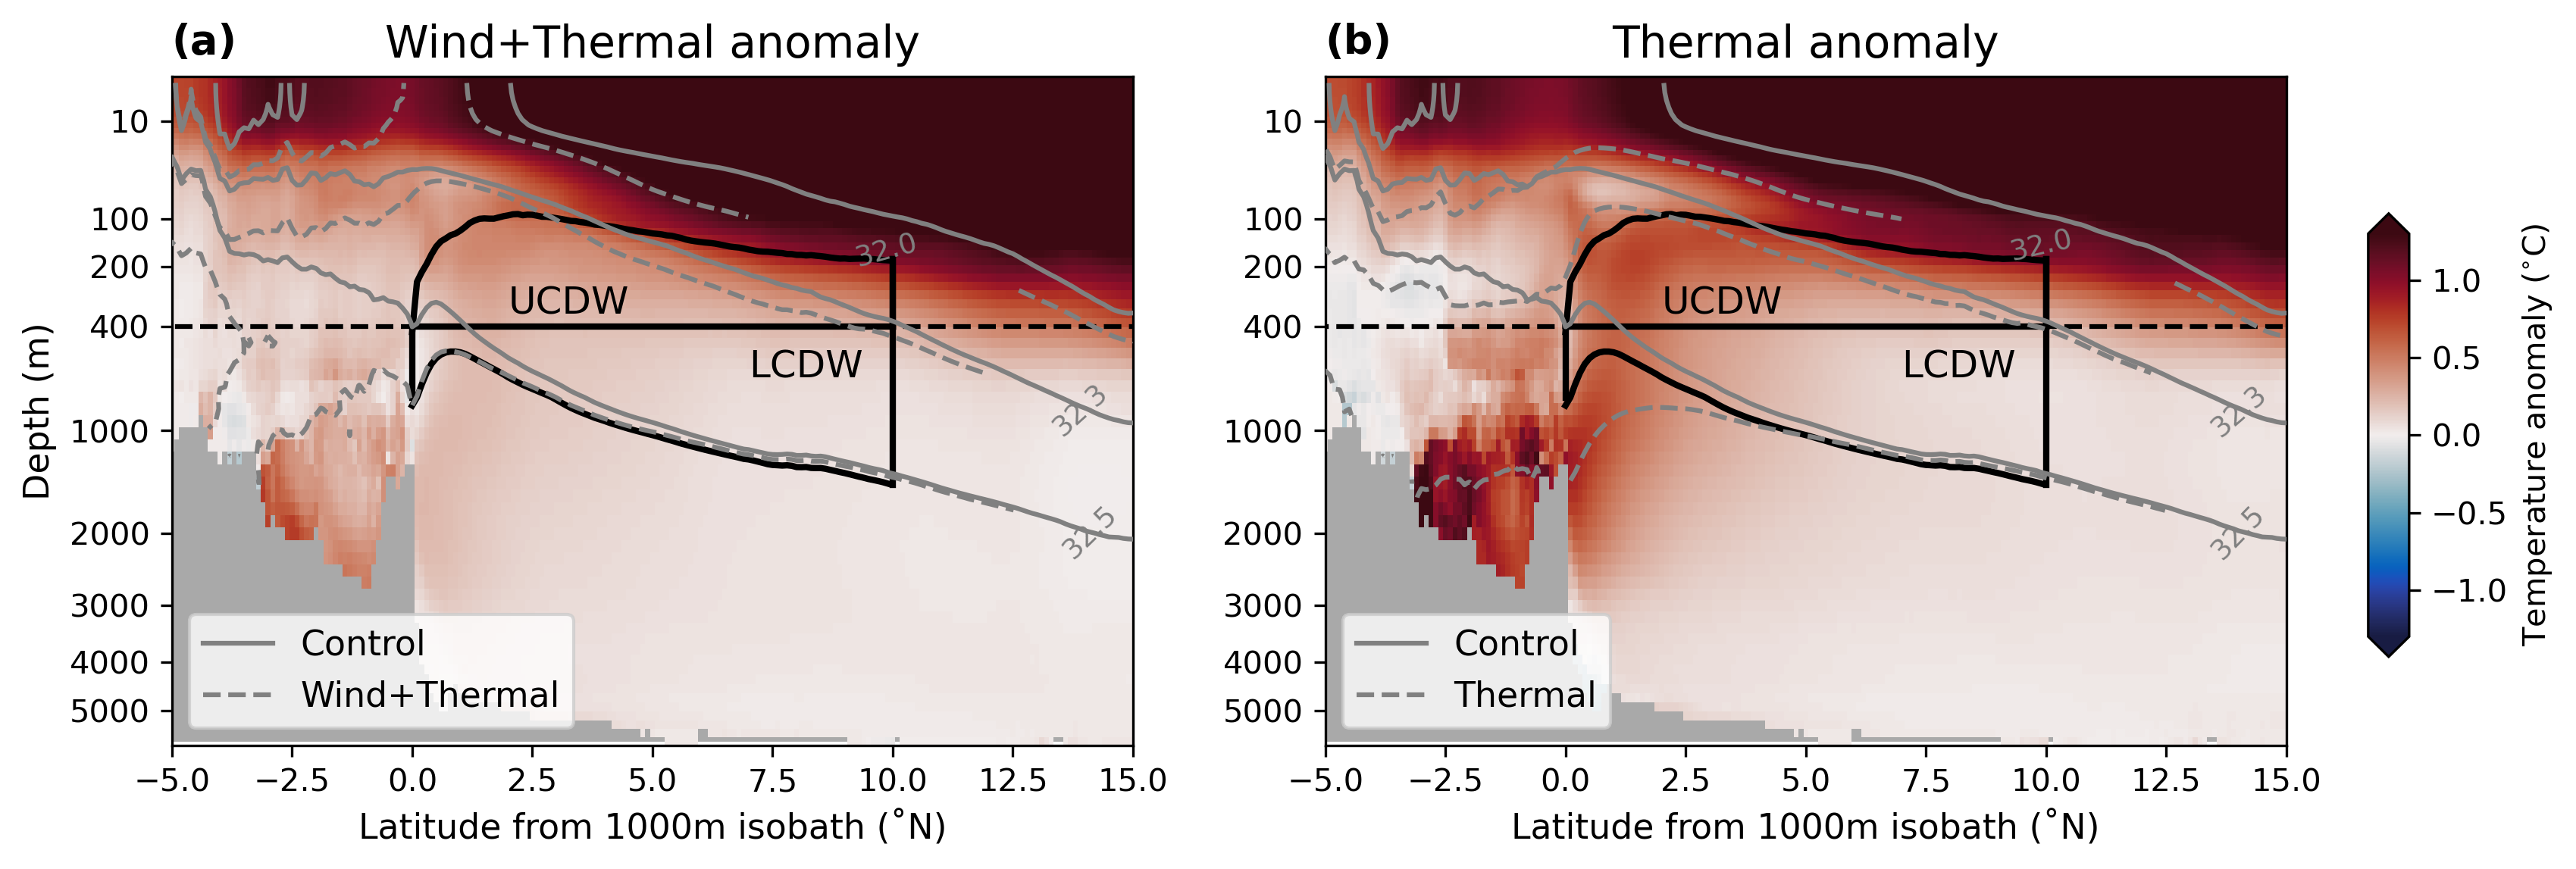

In [31]:
# For Figure 5
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
fig = plt.figure(figsize=(12,13),dpi = 300)
# transect 
ax = plt.subplot(3,2,5)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Wind+Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (temp_wt_mean_new.sel(st_ocean = slice(1.,8000))-temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-1.3,vmax=1.3, cmap = cm.cm.balance,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_wt_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)

#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.yticks([10.,1000,2000,3000,4000,5000], [10.,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Wind+Thermal anomaly', fontsize = 14)
ax.text(
       0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
ax = plt.subplot(3,2,6)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (temp_th_mean_new.sel(st_ocean = slice(1.,8000))-temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-1.3,vmax=1.3, cmap = cm.cm.balance,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel(' ', fontsize = 12)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
ax.set_title('Thermal anomaly', fontsize = 14)
ax.text(
        0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
# colorbar 
ax_cb2 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature anomaly ($^{\circ}$C)', fontsize = 10)